In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet, TrajNet
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.planner import DiffuserPlanner
from timeskip_diffuser.diffuser.reward import CompositeReward, GoalReachingReward, PathLengthPenalty, StartReachingReward
from timeskip_diffuser.datasets.point_maze.umaze import UMazeFlatDataset
import torch

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [46]:
dataset = UMazeFlatDataset(horizon=160)

In [47]:
len(dataset)

8594

In [135]:
net_type = "unet"

match net_type:
    case "eqnet":
        net_class = EqNet
        ckpt = "C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\pipelines\\runs\\umaze_eqnet_seed0_20251220_223627\\checkpoints\\diffuser_eqnet_epoch_20.pt"
    case "unet":
        net_class = TemporalUNet
        ckpt = "C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\pipelines\\runs\\umaze_unet_seed0_20251221_002135\\checkpoints\\diffuser_unet_epoch_10.pt"

In [136]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = net_class(
    state_dim=dataset.state_dim,
    time_dim=32,
)
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(model, diffusion, dataset, lr=1e-4, device=device)
trainer.load_checkpoint(ckpt)
planner = DiffuserPlanner(model, diffusion, dataset, device=device)

Using device: cuda


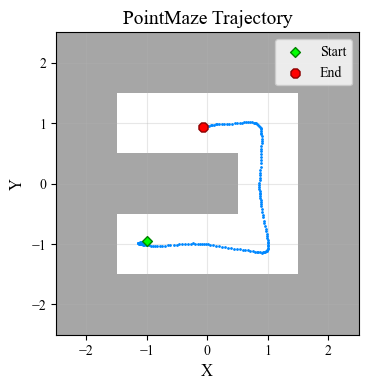

In [137]:
traj_norm = random.choice(dataset)
traj = dataset.denormalize(traj_norm)
dataset.visualize(traj)

In [138]:
current = traj[0].numpy().copy()
goal = traj[-1].numpy().copy()
print(current, goal)

[-1.00371   -0.9501041] [-0.06820922  0.94291774]


In [139]:
reward_fn = CompositeReward([
    StartReachingReward(current[:2], reward_scale=5.0),  # Increased from 10
    GoalReachingReward(goal, reward_scale=5.0),          # Keep balanced
    PathLengthPenalty(reward_scale=0.2),                  # Reduced from 0.5!
])

traj_model = planner.plan(
    current, goal,
    horizon=160,
    reward_fn=reward_fn,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=1.0,
)
print(f"Start (actual): {traj_model[0, :2]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(traj_model[0, :2] - current[:2]):.4f}")
print(f"End: {traj_model[-1, :2]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(traj_model[-1, :2] - goal):.4f}")

# Check for discontinuities (physics violations)
diffs = np.linalg.norm(traj_model[1:, :2] - traj_model[:-1, :2], axis=1)
max_jump = diffs.max()
print(f"Max step size: {max_jump:.4f}")
if max_jump > 0.2:  # Adjust threshold based on your maze
    print("  ⚠️  WARNING: Large discontinuity detected!")
else:
    print("  ✓ Trajectory appears continuous")

Start (actual): [-1.00347613 -0.94995141]
Start (target): [-1.00371   -0.9501041]
Start error: 0.0003
End: [-0.06813061  0.94275624]
Goal: [-0.06820922  0.94291774]
Goal error: 0.0002
Max step size: 0.7135
  ⚠️  WARNING: Large discontinuity detected!


In [140]:
traj_model.shape

(160, 2)

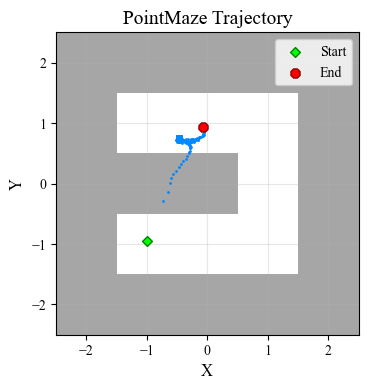

In [141]:
dataset.visualize(traj_model)